# Przygotowanie modelu regresji

In [1]:
# standardowe przetwarzanie danych
import pandas as pd
import numpy as np

# wykresy
import matplotlib.pyplot as plt
import seaborn as sns

# biblioteki do przygotowania modelu
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# można też użyć pickle, ale joblib jest bardziej efektywne dla modeli
import joblib

In [2]:
df = pd.read_parquet("ceny_mieszkan_v3.parquet")

## przygotowanie danych
wyciągamy tylko dane numeryczne do korelacji

In [3]:
df_numeric = df.select_dtypes(include=["number"])
df_numeric.columns

Index(['id', 'area', 'price', 'lng', 'lat', 'floor', 'floors', 'balcony',
       'loggia', 'terrace', 'garden', 'price_m2', 'floor_max', 'has_balcony',
       'has_loggia', 'has_terrace', 'has_garden', 'balcony_and_loggia',
       'terrace_and_garden', 'gmina_area', 'distance_to_city_center',
       'distance_to_city_center_round', 'gmina_rodzaj', 'wynagrodzenie',
       'ludnosc'],
      dtype='object')

In [4]:
df_numeric["gmina_area_per_person"] = df_numeric["gmina_area"]/df_numeric["ludnosc"]

### Macierz korelacji

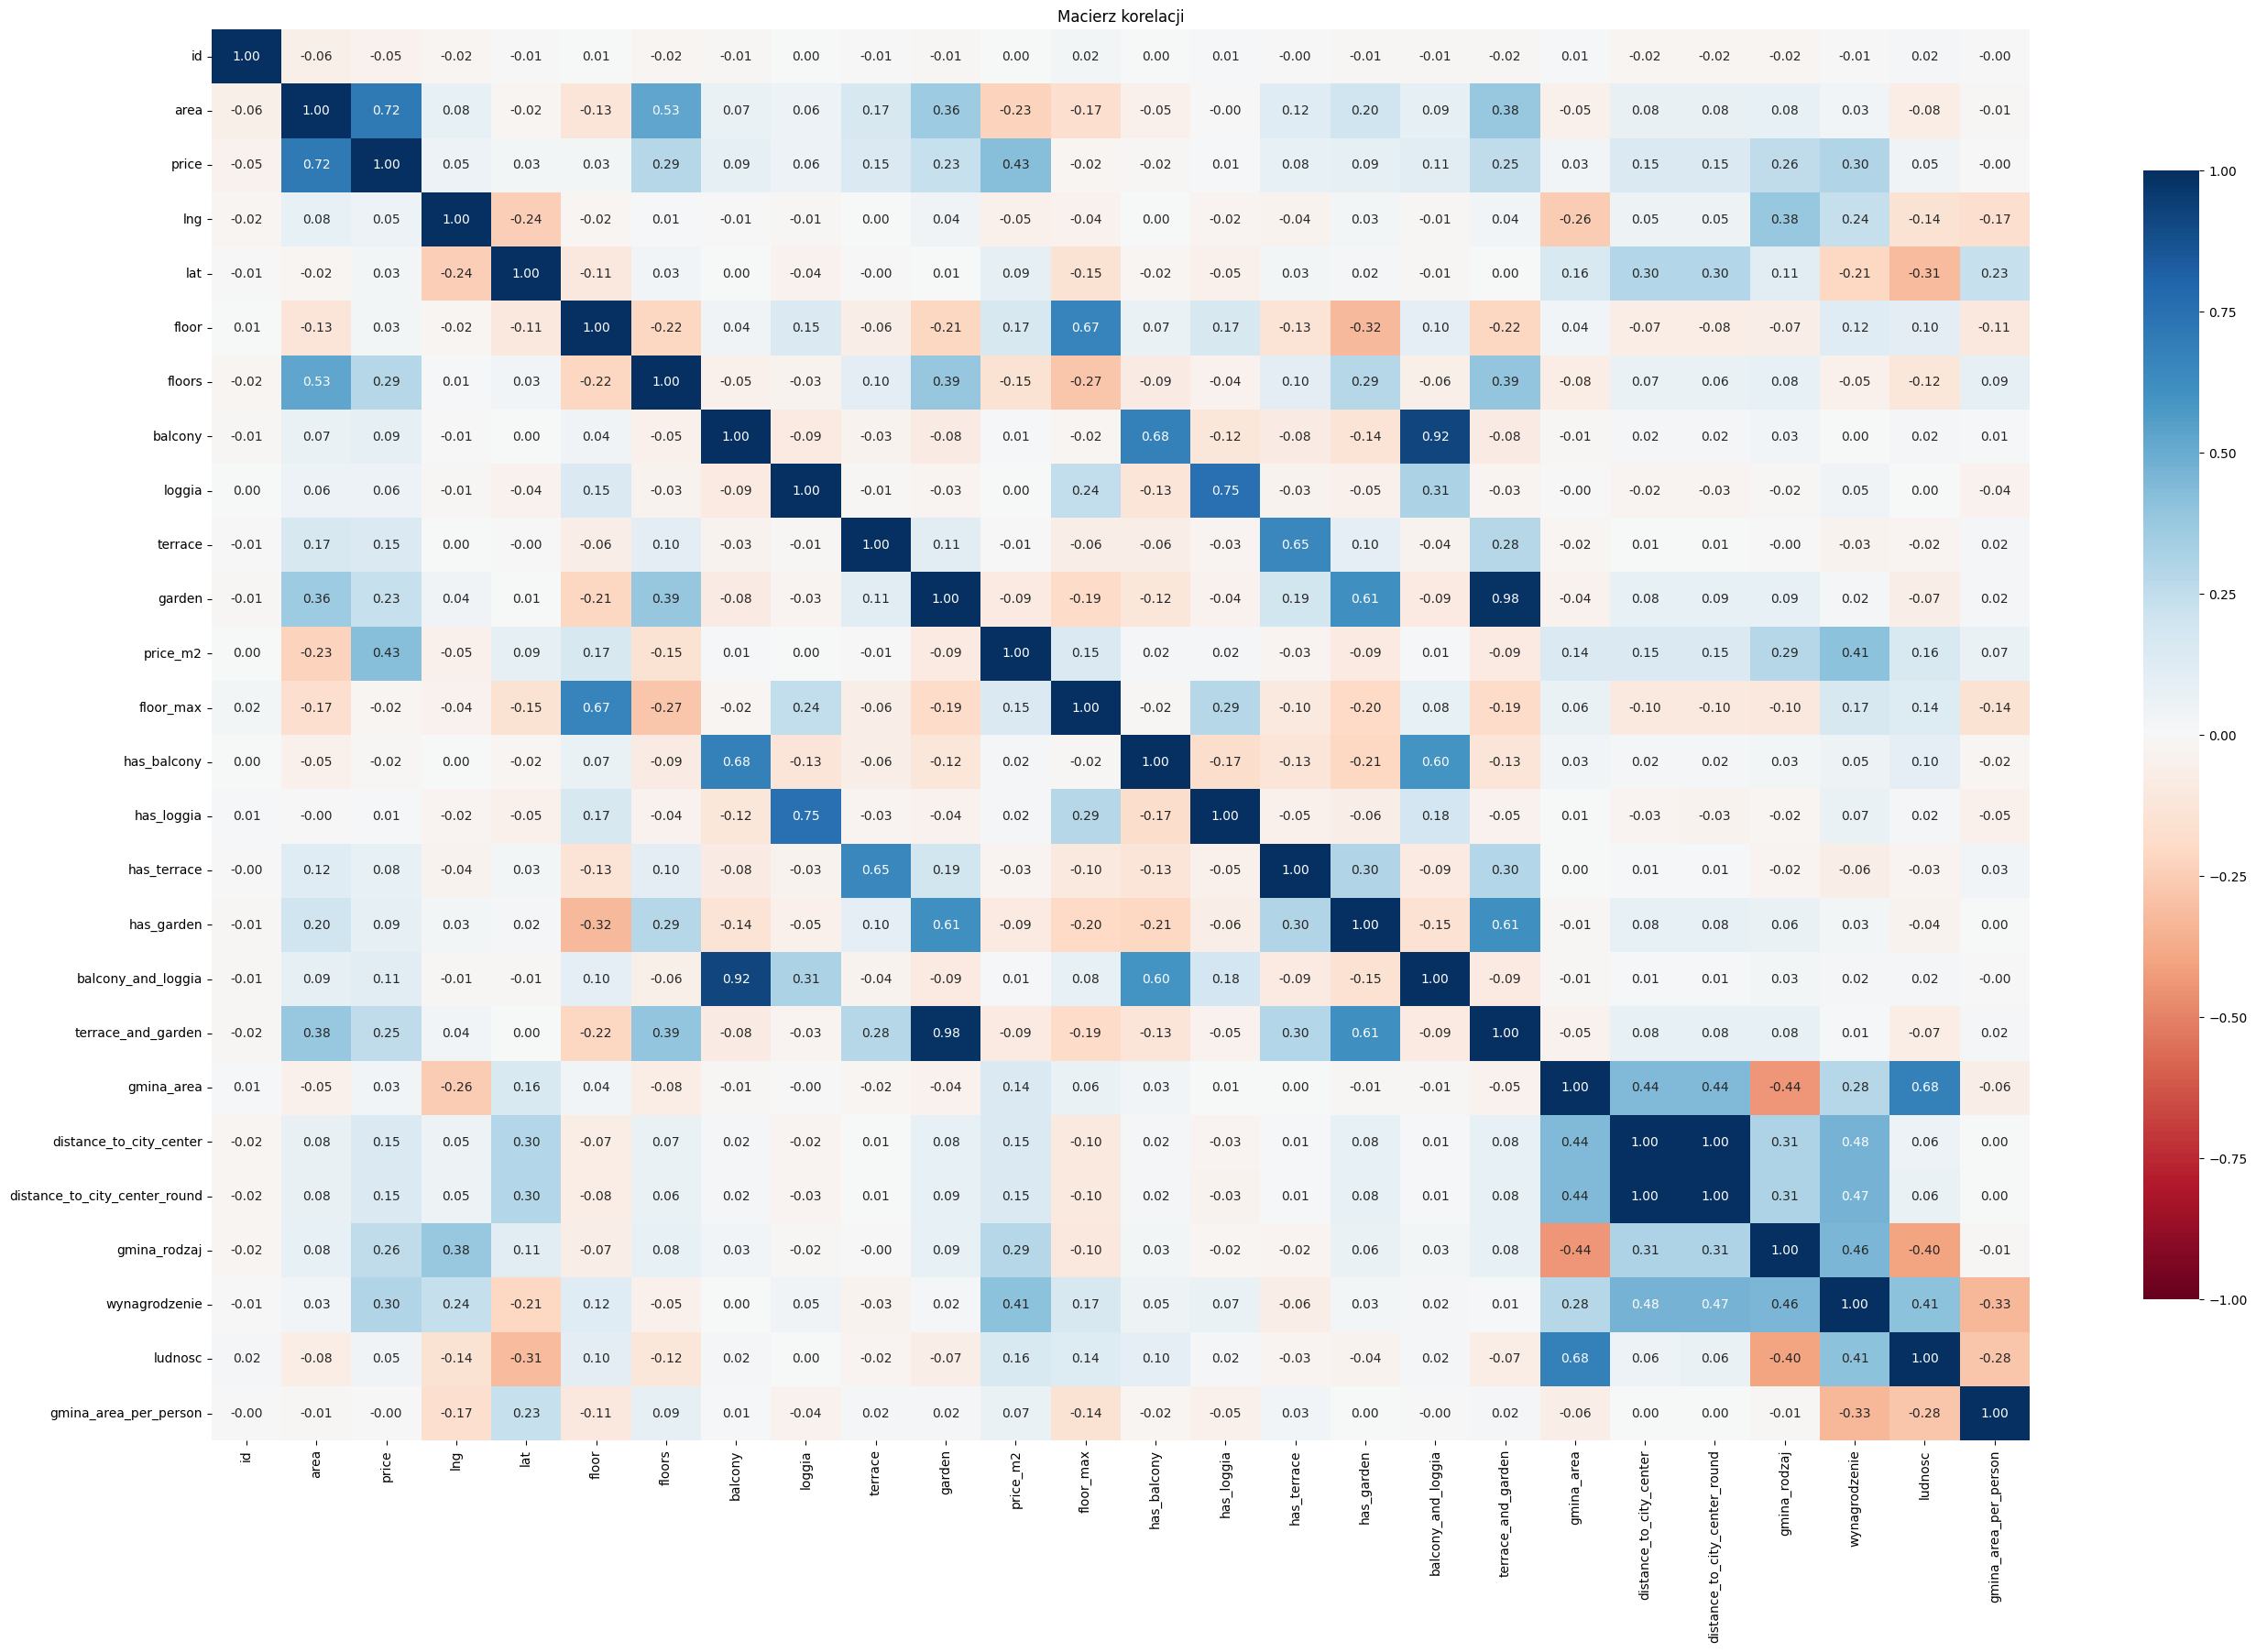

In [5]:
corr=df_numeric.corr()

plt.figure(figsize=(32,20))
sns.heatmap(
    data= corr,
    cmap="RdBu",
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
    center=0,
    vmin=-1,
    vmax=1,   
)

plt.title("Macierz korelacji")
plt.show()

### Wykres korelacji tylko dla price_m2

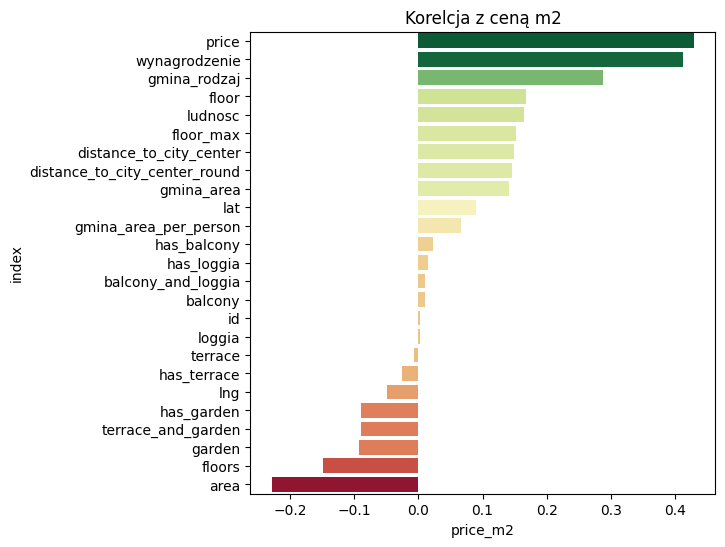

In [6]:
plot_data = corr[["price_m2"]].reset_index().sort_values("price_m2", ascending=False)
plot_data = plot_data[plot_data["index"] != "price_m2"]

plt.figure(figsize=(6,6))
sns.barplot(
    data=plot_data,
    y="index",
    x="price_m2",
    hue="price_m2",
    legend=False,
    palette="RdYlGn",
)
plt.title("Korelcja z ceną m2")
plt.show()

In [7]:
df.value_counts('loggia')

loggia
0.00     84872
1.87       107
2.72        91
2.76        89
5.60        84
         ...  
27.24        1
26.76        1
26.75        1
26.74        1
2.08         1
Name: count, Length: 1093, dtype: int64

In [8]:
df_numeric = df_numeric.drop(columns=[
    "price",
    "distance_to_city_center_round",
    "has_loggia",
    "has_balcony",
    "loggia",
    "has_garden",
    "has_terrace",
    "terrace",
    "id"
])

### Ponowny bar korelacji po odcięciu niepotrzebnych kolumn

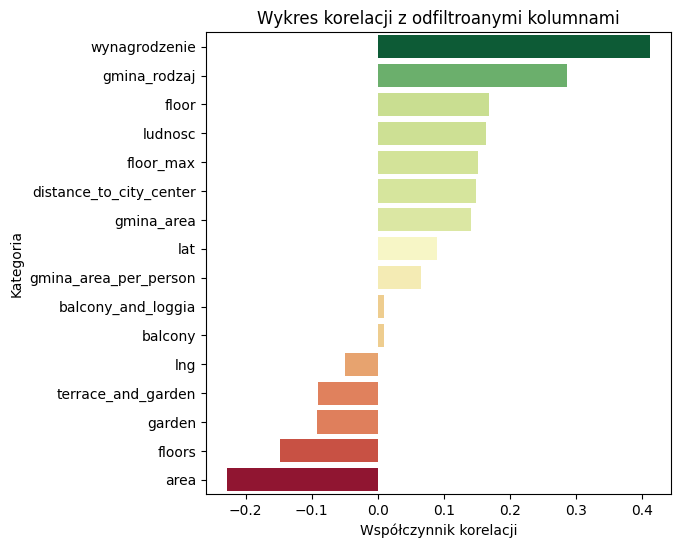

In [9]:
corr = df_numeric.corr()

plot_data = corr["price_m2"].reset_index().sort_values("price_m2", ascending=False)
plot_data = plot_data[plot_data["index"] != "price_m2"]

plt.figure(figsize=(6,6))

sns.barplot(
    data=plot_data,
    y="index",
    x= "price_m2",
    hue= "price_m2",
    legend=False,
    palette="RdYlGn",
)
plt.title("Wykres korelacji z odfiltroanymi kolumnami")
plt.xlabel("Współczynnik korelacji")
plt.ylabel("Kategoria")
plt.show()


## Podział na modele testowe, walidacyjne i treningowe

Warto mieć ten kod jako podstawa do skopiowania:

 co jest targetem?
target_col = "price_m2"

 jaką część ma stanowić test, jaką walidacja?
test_size = 0.2
val_size = 0.1

 dla zniwelowania losowości podziału i utrzymania powtarzalności
 wyników, to może być dowolna liczba
random_state = 42

In [10]:
# wycięcie kolumny targetowej
X = df_numeric.drop(columns=["price_m2"])   #kolumny do badania regresji - cechy
y = df_numeric["price_m2"]                  #kolumna targetowa


#podział na treningowy i temp (test i walidację)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)   #przyjmuje się żeby ten podział losowy był taki sam przy różnych wywołaniach, liczba 42 przyjęła się jako żart

#zbiór walidacyjny

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42
)

In [ ]:
# wielkość naszych zbiorów
print(f"Całość    : {len(df_numeric):>6}")
print(f"Trening   : {len(y_train):>6} = {len(y_train) / len(df_numeric):.1%}")
print(f"Test      : {len(y_test):>6} = {len(y_test) / len(df_numeric):.1%}")
print(f"Walidacja : {len(y_val):>6} = {len(y_val) / len(df_numeric):.1%}")

Całość    :  91469
Trening   :  64028 = 70.0%
Test      :  18294 = 20.0%
Walidacja :   9147 = 10.0%


In [12]:
#rozwiązanie z kursu
# # co jest targetem?
# target_col = "price_m2"

# # jaką część ma stanowić test, jaką walidacja?
# test_size = 0.2
# val_size = 0.1

# # dla zniwelowania losowości podziału i utrzymania powtarzalności
# # wyników, to może być dowolna liczba
# random_state = 42

# # X to cechy, y to target
# X = df_numeric.drop(columns=[target_col]) # wszystko bez targetu
# y = df_numeric[target_col]

# # Podział na zbiór treningowy i tymczasowy (testowy + walidacyjny)
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y,
#     test_size=(test_size + val_size),
#     random_state=random_state
# )

# # Podział zbioru tymczasowego na testowy i walidacyjny
# # Proporcja walidacyjnego względem X_temp:
# test_ratio = test_size / (test_size + val_size)
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=test_ratio,
#     random_state=random_state
# )

## Budowa modelu

In [ ]:
# budujemy model - wszystkie parametry są domyślne!
model = xgb.XGBRegressor(objective="reg:squarederror",
    random_state=42)

# trening na pełnym zbiorze treningowym
# plus testowanie podczas uczenia na zbiorze testowym
model.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
)

[0]	validation_0-rmse:3577.20191
[1]	validation_0-rmse:3030.47964
[2]	validation_0-rmse:2669.94761
[3]	validation_0-rmse:2460.45072
[4]	validation_0-rmse:2296.02753
[5]	validation_0-rmse:2167.28060
[6]	validation_0-rmse:2095.77072
[7]	validation_0-rmse:2037.61724
[8]	validation_0-rmse:1996.27455
[9]	validation_0-rmse:1967.17878
[10]	validation_0-rmse:1929.09121
[11]	validation_0-rmse:1893.17451
[12]	validation_0-rmse:1830.80968
[13]	validation_0-rmse:1813.66491
[14]	validation_0-rmse:1761.14846
[15]	validation_0-rmse:1746.24491
[16]	validation_0-rmse:1735.02745
[17]	validation_0-rmse:1683.56181
[18]	validation_0-rmse:1676.36496
[19]	validation_0-rmse:1661.11401
[20]	validation_0-rmse:1649.51309
[21]	validation_0-rmse:1624.78019
[22]	validation_0-rmse:1609.25390
[23]	validation_0-rmse:1588.80511
[24]	validation_0-rmse:1554.73483
[25]	validation_0-rmse:1544.15640
[26]	validation_0-rmse:1537.84265
[27]	validation_0-rmse:1513.43285
[28]	validation_0-rmse:1488.92347
[29]	validation_0-rmse:1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### Sprawdzanie modelu

In [14]:
y_pred = model.predict(X_val)

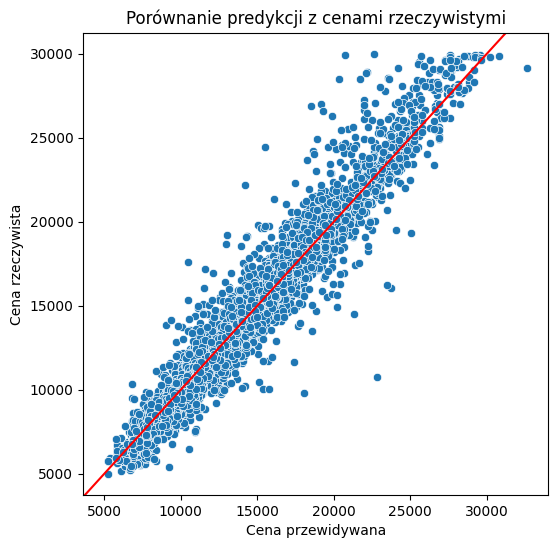

In [15]:
fig = plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_pred, y=y_val
)

#ograniczamy ceny do 5-30k
plt.axline((5000,5000),(30000,30000), c="red")
plt.title("Porównanie predykcji z cenami rzeczywistymi")
plt.xlabel("Cena przewidywana")
plt.ylabel("Cena rzeczywista")
plt.show()

### Obliczenie błędu średniokwadratowego

In [16]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {rmse:.4f}")

Validation RMSE: 1005.0355


In [ ]:
# budujemy model - wszystkie parametry są domyślne!
model = xgb.XGBRegressor(objective="reg:squarederror",
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth= 10,
    subsample=0.6,
    colsample_bytree=0.7
    )

# trening na pełnym zbiorze treningowym
# plus testowanie (eval-uacja) podczas uczenia na zbiorze testowym
model.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
)

[0]	validation_0-rmse:4145.78458
[1]	validation_0-rmse:3992.75684
[2]	validation_0-rmse:3849.39972
[3]	validation_0-rmse:3705.68977
[4]	validation_0-rmse:3597.89685
[5]	validation_0-rmse:3472.13966
[6]	validation_0-rmse:3346.27117
[7]	validation_0-rmse:3222.13379
[8]	validation_0-rmse:3114.62790
[9]	validation_0-rmse:3003.00960
[10]	validation_0-rmse:2896.82432
[11]	validation_0-rmse:2805.66992
[12]	validation_0-rmse:2733.99452
[13]	validation_0-rmse:2644.68811
[14]	validation_0-rmse:2558.23422
[15]	validation_0-rmse:2475.28858
[16]	validation_0-rmse:2403.80485
[17]	validation_0-rmse:2340.26365
[18]	validation_0-rmse:2267.20071
[19]	validation_0-rmse:2200.39063
[20]	validation_0-rmse:2142.48449
[21]	validation_0-rmse:2084.89917
[22]	validation_0-rmse:2032.32420
[23]	validation_0-rmse:1976.26452
[24]	validation_0-rmse:1934.78573
[25]	validation_0-rmse:1888.32269
[26]	validation_0-rmse:1844.65071
[27]	validation_0-rmse:1807.96880
[28]	validation_0-rmse:1774.09530
[29]	validation_0-rmse:1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

Validation RMSE: 820.5970


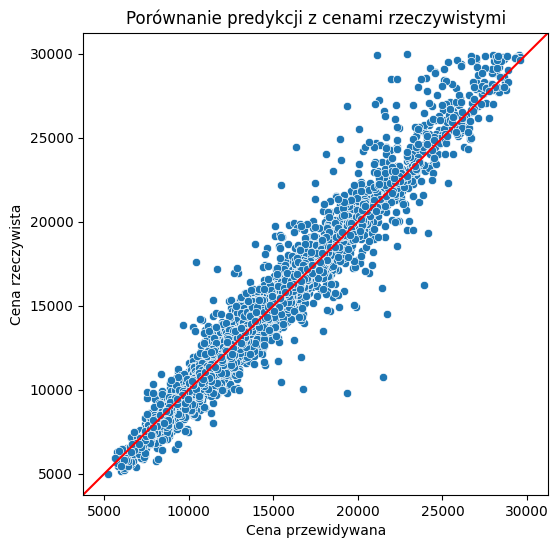

In [25]:
y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {rmse:.4f}")

fig = plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_pred, y=y_val
)

#ograniczamy ceny do 5-30k
plt.axline((5000,5000),(30000,30000), c="red")
plt.title("Porównanie predykcji z cenami rzeczywistymi")
plt.xlabel("Cena przewidywana")
plt.ylabel("Cena rzeczywista")
plt.show()

## Zapis modelu

In [26]:
joblib.dump(model, "model_all.pkl")

['model_all.pkl']

## Zadania dodatkowe
Przede wszystkim - rozbić zbiór danych na części kraju (na przykład województwa, albo i dodatkowo duże miasta) i dla każdej z nich wyuczyć oddzielny model:

- Sprawdź i wybierz samą Warszawę, wyucz model, zobacz czy (bez kręcenia hiperparametrami) RSME będzie podobne (u mnie od razu było około 780)?
- A teraz wybierz tylko województwo małopolskie (dlaczego? zobacz do odcinka drugiego i zastanów się) - u mnie RMSE to 895.

W obu przypadkach lepiej niż na całej próbie. Warto wziąć pod uwagę dedykowany model dla pewnego - merytorycznie uzasadnionego - podzbioru danych i tylko jego użyć.

Czasem stosuje się też technikę (bagging), w której wyniki z wielu modeli łączy się w jeden na przykład uśredniając albo głosując (to prędzej przy klasyfikacji).

Można wykorzystać też stacking - czyli dodatkowy meta-model model, który wybierze odpowiedni wynik z wyników małych modeli.

### Sama Warszawa

In [41]:
#df_selected = df[df["city"]=="Warszawa"]
df_selected = df[df["voivodeship"]=="wielkopolskie"]

df_numeric = df_selected.select_dtypes(include=["number"])
df_numeric["gmina_area_per_person"] = df_numeric["gmina_area"]/df_numeric["ludnosc"]

df_numeric = df_numeric.drop(columns=[
    "price",
    "distance_to_city_center_round",
    "has_loggia",
    "has_balcony",
    "loggia",
    "has_garden",
    "has_terrace",
    "terrace",
    "id"
])

corr = df_numeric.corr()

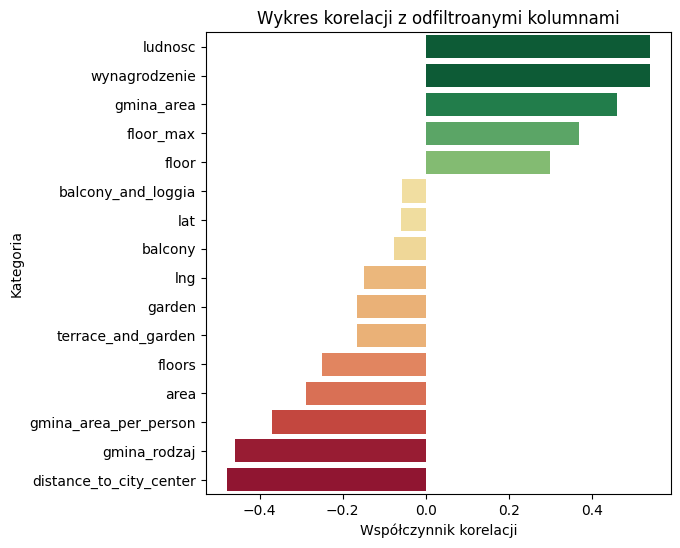

In [42]:
plot_data = corr["price_m2"].reset_index().sort_values("price_m2", ascending=False)
plot_data = plot_data[plot_data["index"] != "price_m2"]

plt.figure(figsize=(6,6))

sns.barplot(
    data=plot_data,
    y="index",
    x= "price_m2",
    hue= "price_m2",
    legend=False,
    palette="RdYlGn",
)
plt.title("Wykres korelacji z odfiltroanymi kolumnami")
plt.xlabel("Współczynnik korelacji")
plt.ylabel("Kategoria")
plt.show()


In [43]:
X = df_numeric.drop(columns=["price_m2"])   #kolumny do badania regresji - cechy
y = df_numeric["price_m2"]                  #kolumna targetowa


#podział na treningowy i temp (test i walidację)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)   #przyjmuje się żeby ten podział losowy był taki sam przy różnych wywołaniach, liczba 42 przyjęła się jako żart

#zbiór walidacyjny

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42
)


# wielkość naszych zbiorów
print(f"Całość    : {len(df_numeric):>6}")
print(f"Trening   : {len(y_train):>6} = {len(y_train) / len(df_numeric):.1%}")
print(f"Test      : {len(y_test):>6} = {len(y_test) / len(df_numeric):.1%}")
print(f"Walidacja : {len(y_val):>6} = {len(y_val) / len(df_numeric):.1%}")

Całość    :   8381
Trening   :   5866 = 70.0%
Test      :   1676 = 20.0%
Walidacja :    839 = 10.0%


In [44]:
# budujemy model - wszystkie parametry są domyślne!
model = xgb.XGBRegressor(objective="reg:squarederror",
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth= 10,
    subsample=0.6,
    colsample_bytree=0.7
    )

# trening na pełnym zbiorze treningowym
# plus testowanie (eval-uacja) podczas uczenia na zbiorze testowym
model.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
)

[0]	validation_0-rmse:3362.79465
[1]	validation_0-rmse:3220.42584
[2]	validation_0-rmse:3076.39847
[3]	validation_0-rmse:2939.57454
[4]	validation_0-rmse:2844.28242
[5]	validation_0-rmse:2719.23304
[6]	validation_0-rmse:2599.61171
[7]	validation_0-rmse:2488.11734
[8]	validation_0-rmse:2381.78132
[9]	validation_0-rmse:2282.33705
[10]	validation_0-rmse:2186.22766
[11]	validation_0-rmse:2095.53564
[12]	validation_0-rmse:2028.87561
[13]	validation_0-rmse:1944.49064
[14]	validation_0-rmse:1867.58190
[15]	validation_0-rmse:1793.07406
[16]	validation_0-rmse:1722.35049
[17]	validation_0-rmse:1656.94197
[18]	validation_0-rmse:1597.01428
[19]	validation_0-rmse:1538.28090
[20]	validation_0-rmse:1482.69307
[21]	validation_0-rmse:1427.33777
[22]	validation_0-rmse:1378.78436
[23]	validation_0-rmse:1331.34613
[24]	validation_0-rmse:1290.39280
[25]	validation_0-rmse:1246.51474
[26]	validation_0-rmse:1208.44074
[27]	validation_0-rmse:1172.97149
[28]	validation_0-rmse:1138.40014
[29]	validation_0-rmse:1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

Validation RMSE: 536.1171


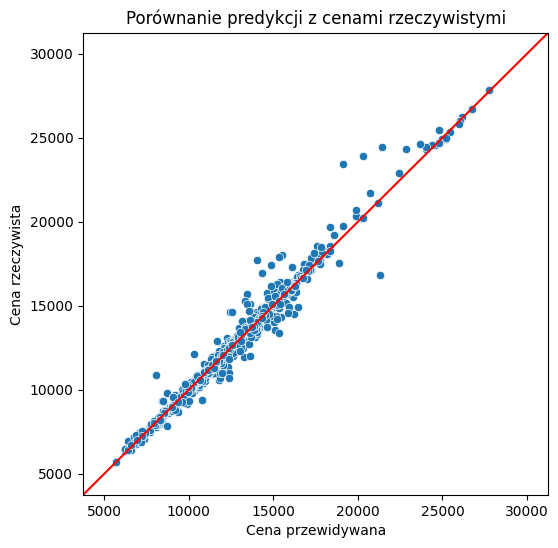

In [45]:
y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {rmse:.4f}")

fig = plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_pred, y=y_val
)

#ograniczamy ceny do 5-30k
plt.axline((5000,5000),(30000,30000), c="red")
plt.title("Porównanie predykcji z cenami rzeczywistymi")
plt.xlabel("Cena przewidywana")
plt.ylabel("Cena rzeczywista")
plt.show()